# Config B - Continuous-State ICU-Sepsis (Deep RL)

This notebook **only calls** the implementation in [`sepsis_rl.py`](sepsis_rl.py).
All the agent / training / evaluation / plotting logic lives there; here we just
run it and look at the results. Every figure is saved to the **`outputs/`** directory.

**Action space is `Discrete(25)`** (5 vasopressor x 5 IV-fluid levels) - the same as
Config A. What is continuous in Config B is the **observation** (47-dim clinical
feature vector). We therefore use the discrete-action algorithms **DQN, PPO, A2C**.

| Run | Normalization | Purpose |
|-----|---------------|---------|
| DQN, PPO (v1) | none | baseline on raw observations |
| DQN-v2, PPO-v2, A2C | VecNormalize | clean ablation: effect of obs normalization |

In [13]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sepsis_rl as srl

srl.ensure_dirs(srl.OUTPUT_DIR, srl.MODELS_DIR, srl.LOGS_DIR)
print('Device           :', srl.DEVICE)
print('Plots saved to   :', srl.OUTPUT_DIR + '/')
print('Algorithms       :', list(srl.ALGOS))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device           : cpu
Plots saved to   : outputs/
Algorithms       : ['DQN', 'PPO', 'A2C']


## 1. Environment & random baseline

The full clinical environment (`make_clinical_env`) stacks three failure-mode
wrappers on top of the continuous base env: episodic observation noise, episodic
missing labs, and rare acute death events. The random policy is the target to beat.

In [14]:
from envs.wrappers import make_clinical_env

env = make_clinical_env()
print('Observation space:', env.observation_space)
print('Action space     :', env.action_space)
env.close()

# Random baseline (use 1000 episodes for the report)
random_stats = srl.random_baseline(n_episodes=1000)
RANDOM_RETURN = random_stats['return']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space: Box(-inf, inf, (47,), float32)
Action space     : Discrete(25)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] return=0.5765  survival=66.9%


## 2. Training

`TIMESTEPS` controls the budget. Default is **fast** (a few minutes per agent).
For final, report-quality results set it to `1_000_000` (several hours total).

In [15]:
TIMESTEPS = 150_000      # <- para resultados finais usa 1_000_000
EVAL_FREQ = 5_000
N_EVAL    = 200           # aumentado de 50 para curvas mais suaves

# --- v1: raw observations (no normalization) ---
_, dqn_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[dqn] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo] training complete (150,000 steps).


### v2: with `VecNormalize`

The 47 features live on wildly different scales, so normalizing observations is the
single biggest lever for these agents. v2 changes **only** the normalization vs v1.

In [16]:
_, dqn2_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo2_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, a2c_tag  = srl.train_agent('A2C', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[dqn_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[a2c_v2] training complete (150,000 steps).


## 3. Learning curves

Read from each run's `evaluations.npz`, EMA-smoothed (faint line = raw eval returns).

Saved outputs\configB_learning_curves.png


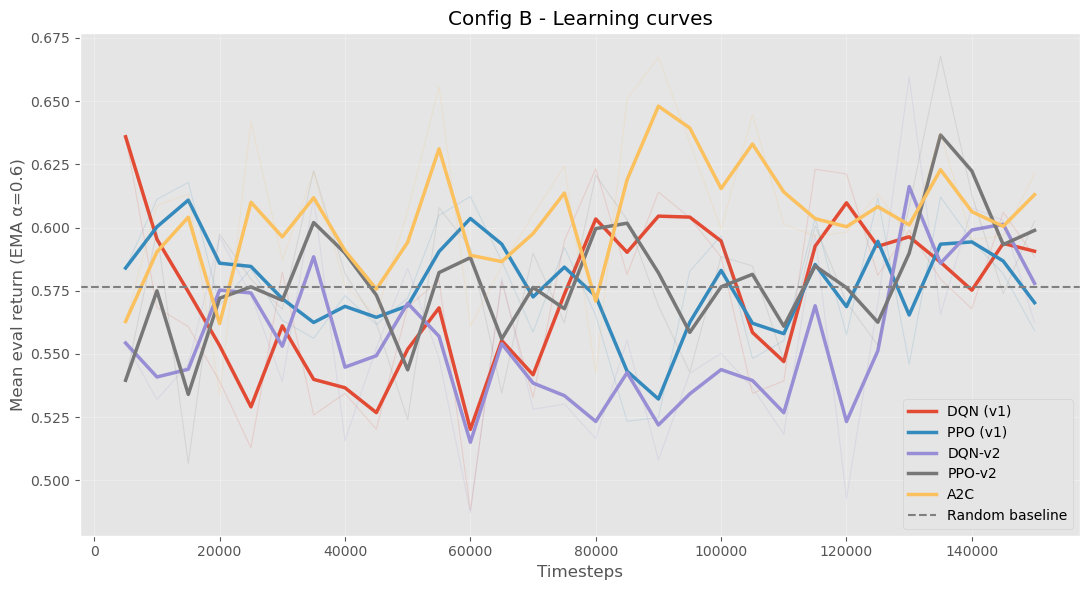

Saved outputs\configB_learning_curves_zoom.png


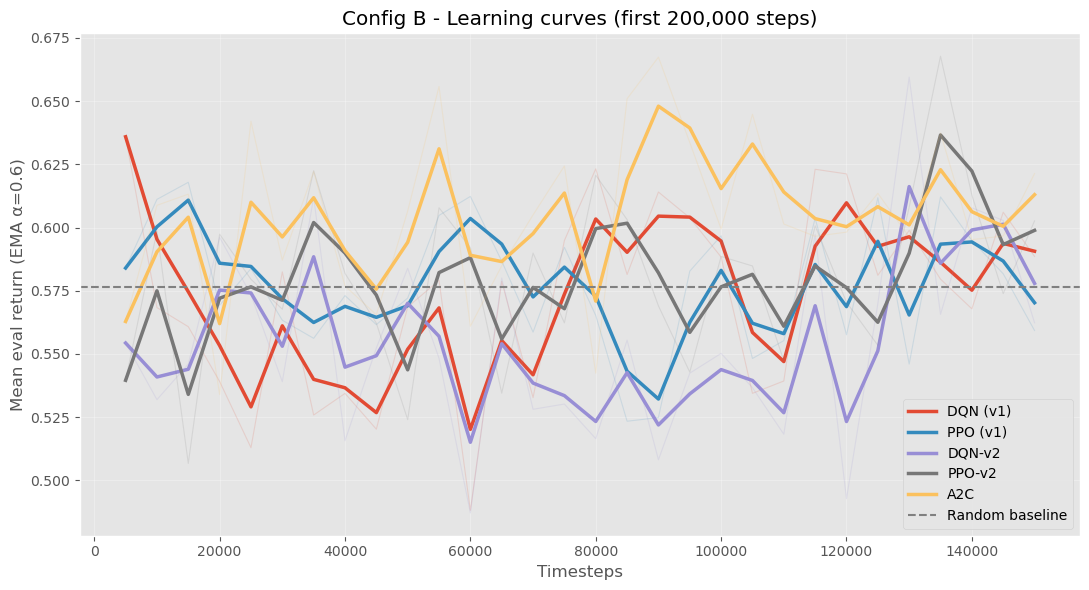

'outputs\\configB_learning_curves_zoom.png'

In [17]:
# Curva completa (todos os passos)
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
)

# Zoom nos primeiros 200k passos - onde a aprendizagem acontece
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
    zoom_steps=200_000,
    filename='configB_learning_curves_zoom.png',
)

## 4. Robustness evaluation

Each agent is evaluated on its own env per failure mode (Clean / Noisy / Missing /
Acute / All). Survival is read from the terminal reward (death -> 0, survival -> ~1).

In [28]:
N_EVAL_EPISODES = 1000     # 1000 for the report

results = {
    'DQN (v1)': srl.evaluate_conditions(dqn_tag,  'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO (v1)': srl.evaluate_conditions(ppo_tag,  'PPO', n_episodes=N_EVAL_EPISODES),
    'DQN-v2':   srl.evaluate_conditions(dqn2_tag, 'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO-v2':   srl.evaluate_conditions(ppo2_tag, 'PPO', n_episodes=N_EVAL_EPISODES),
    'A2C':      srl.evaluate_conditions(a2c_tag,  'A2C', n_episodes=N_EVAL_EPISODES),
}

srl.results_table(results, random_ret=RANDOM_RETURN, condition='All')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn] All      n=1000  return=0.5704  survival=64.9%
[dqn] Clean    n= 670  return=0.6185  survival=69.7%
[dqn] Noisy    n= 144  return=0.6395  survival=72.2%
[dqn] Missing  n= 151  return=0.5553  survival=62.9%
[dqn] Acute    n=  78  return=-0.0762  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo] All      n=1000  return=0.5727  survival=64.1%
[ppo] Clean    n= 658  return=0.6438  survival=71.3%
[ppo] Noisy    n= 149  return=0.5080  survival=57.0%
[ppo] Missing  n= 151  return=0.5888  survival=65.6%
[ppo] Acute    n=  88  return=-0.0692  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_v2] All      n=1000  retu

,Agent,Return (All),Survival (All),vs Random
0,DQN (v1),0.5704,64.9%,-1.0%
1,PPO (v1),0.5727,64.1%,-0.7%
2,DQN-v2,0.5846,66.0%,+1.4%
3,PPO-v2,0.5961,67.0%,+3.4%
4,A2C,0.6131,66.0%,+6.3%


Saved outputs\configB_robustness_return.png


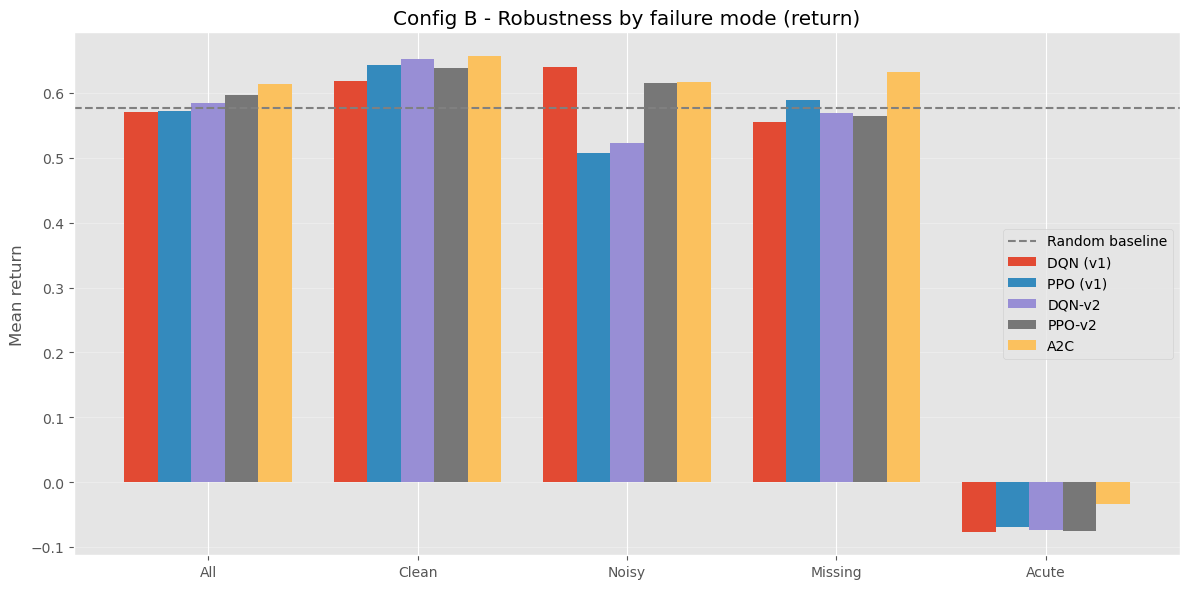

Saved outputs\configB_robustness_survival.png


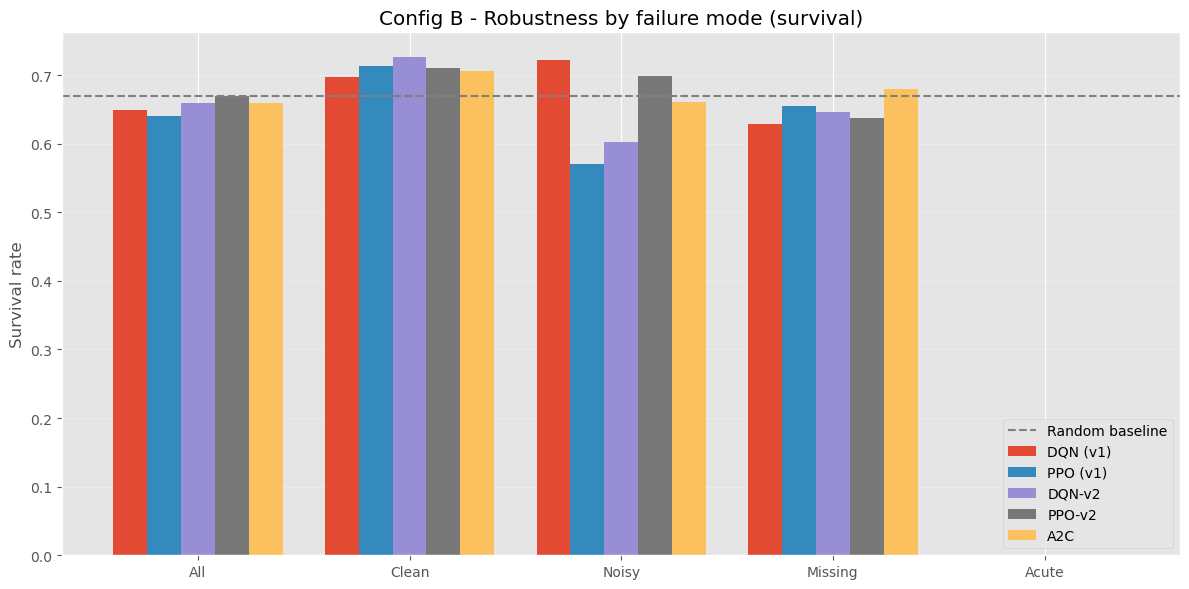

'outputs\\configB_robustness_survival.png'

In [29]:
srl.plot_robustness(results, metric='return',   baseline=RANDOM_RETURN,
                    filename='configB_robustness_return.png')
srl.plot_robustness(results, metric='survival', baseline=random_stats['survival'],
                    filename='configB_robustness_survival.png')

## 5. Hyperparameter tuning (Optuna)

Short proxy budget (`timesteps=50k`, few trials) - enough to find good regions
without the full multi-hour training. Increase `n_trials` / `timesteps` if you have
time. History + parameter-importance plots are saved to `outputs/`.

[I 2026-05-31 14:48:46,039] A new study created in memory with name: DQN_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 14:49:37,239] Trial 0 finished with value: 0.39559999999999995 and parameters: {'learning_rate': 0.00012481128072490977, 'buffer_size': 50000, 'batch_size': 128, 'gamma': 0.9620350409360315, 'train_freq': 8, 'exploration_fraction': 0.18853055748102515, 'target_update_interval': 500}. Best is trial 0 with value: 0.39559999999999995.


[dqn_optuna_t0] All      n=  50  return=0.3956  survival=50.0%
[dqn_optuna_t0] Clean    n=  26  return=0.5284  survival=61.5%
[dqn_optuna_t0] Noisy    n=   8  return=0.1291  survival=25.0%
[dqn_optuna_t0] Missing  n=  13  return=0.5221  survival=61.5%
[dqn_optuna_t0] Acute    n=   7  return=-0.1646  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 14:50:42,913] Trial 1 finished with value: 0.45635000000000003 and parameters: {'learning_rate': 6.377166179170379e-05, 'buffer_size': 50000, 'batch_size': 64, 'gamma': 0.9757112388384587, 'train_freq': 4, 'exploration_fraction': 0.3749507373079868, 'target_update_interval': 1000}. Best is trial 1 with value: 0.45635000000000003.


...

[dqn_optuna_t12] All      n=  50  return=0.4719  survival=58.0%
[dqn_optuna_t12] Clean    n=  37  return=0.5656  survival=67.6%
[dqn_optuna_t12] Noisy    n=   5  return=0.2545  survival=40.0%
[dqn_optuna_t12] Missing  n=   7  return=0.3500  survival=42.9%
[dqn_optuna_t12] Acute    n=   3  return=-0.2150  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:07:45,302] Trial 13 finished with value: 0.5318999999999999 and parameters: {'learning_rate': 0.00019870487994147454, 'buffer_size': 100000, 'batch_size': 64, 'gamma': 0.9507632558344532, 'train_freq': 8, 'exploration_fraction': 0.3238934878403095, 'target_update_interval': 500}. Best is trial 9 with value: 0.54695.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t13] All      n=  50  return=0.5319  survival=62.0%
[dqn_optuna_t13] Clean    n=  30  return=0.6807  survival=76.7%
[dqn_optuna_t13] Noisy    n=   7  return=0.3539  survival=42.9%
[dqn_optuna_t13] Missing  n=  15  return=0.3582  survival=46.7%
[dqn_optuna_t13] Acute    n=   2  return=-0.0263  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t14] All      n=  50  return=0.5449  survival=64.0%
[dqn_optuna_t14

[I 2026-05-31 15:10:48,096] Trial 14 finished with value: 0.5449 and parameters: {'learning_rate': 0.00024423707033583786, 'buffer_size': 100000, 'batch_size': 64, 'gamma': 0.9555820225674017, 'train_freq': 1, 'exploration_fraction': 0.3124659783276858, 'target_update_interval': 1000}. Best is trial 9 with value: 0.54695.



[DQN] Best value: 0.5470
[DQN] Best params: {'learning_rate': 1.4834994613459502e-05, 'buffer_size': 100000, 'batch_size': 64, 'gamma': 0.9906175826277405, 'train_freq': 4, 'exploration_fraction': 0.3356359763778302, 'target_update_interval': 1000}
Saved outputs\optuna_dqn_history.png


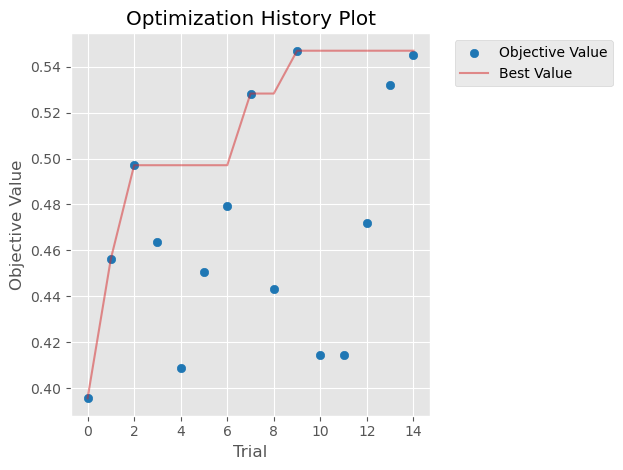

Saved outputs\optuna_dqn_importance.png


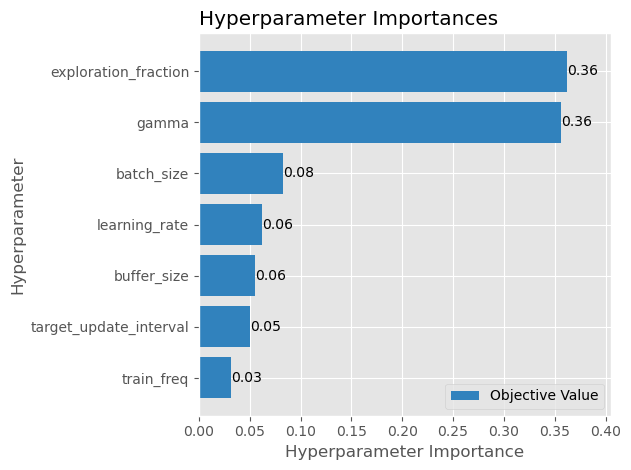

[I 2026-05-31 15:10:48,652] A new study created in memory with name: PPO_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:12:17,964] Trial 0 finished with value: 0.42649999999999993 and parameters: {'n_steps': 512, 'learning_rate': 0.0006917650644399779, 'batch_size': 64, 'gamma': 0.9575931109883435, 'gae_lambda': 0.9627843351809916, 'clip_range': 0.2, 'ent_coef': 0.0008405352467800977}. Best is trial 0 with value: 0.42649999999999993.


[ppo_optuna_t0] All      n=  50  return=0.4265  survival=54.0%
[ppo_optuna_t0] Clean    n=  34  return=0.4526  survival=55.9%
[ppo_optuna_t0] Noisy    n=   9  return=0.3353  survival=44.4%
[ppo_optuna_t0] Missing  n=   8  return=0.4697  survival=62.5%
[ppo_optuna_t0] Acute    n=   4  return=-0.0975  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:13:47,668] Trial 1 finished with value: 0.46214999999999995 and parameters: {'n_steps': 512, 'learning_rate': 7.015843458297864e-05, 'batch_size': 64, 'gamma': 0.9801761869379815, 'gae_lambda': 0.9297280716376792, 'clip_range': 0.2, 'ent_coef': 0.0007382548761031539}. Best is trial 1 with value: 0.46214999999999995.


...

[ppo_optuna_t12] All      n=  50  return=0.4114  survival=50.0%
[ppo_optuna_t12] Clean    n=  27  return=0.5533  survival=63.0%
[ppo_optuna_t12] Noisy    n=  15  return=0.3075  survival=40.0%
[ppo_optuna_t12] Missing  n=   8  return=0.3594  survival=50.0%
[ppo_optuna_t12] Acute    n=   5  return=-0.0510  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:29:20,302] Trial 13 finished with value: 0.5665 and parameters: {'n_steps': 256, 'learning_rate': 0.00020226366185807084, 'batch_size': 128, 'gamma': 0.9871228340453759, 'gae_lambda': 0.9520014919554358, 'clip_range': 0.3, 'ent_coef': 0.004385883505181486}. Best is trial 13 with value: 0.5665.


[ppo_optuna_t13] All      n=  50  return=0.5665  survival=66.0%
[ppo_optuna_t13] Clean    n=  29  return=0.5951  survival=69.0%
[ppo_optuna_t13] Noisy    n=  12  return=0.6927  survival=75.0%
[ppo_optuna_t13] Missing  n=   6  return=0.5000  survival=66.7%
[ppo_optuna_t13] Acute    n=   4  return=-0.0819  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:30:27,556] Trial 14 finished with value: 0.5971 and parameters: {'n_steps': 256, 'learning_rate': 0.00019816091908275718, 'batch_size': 128, 'gamma': 0.9869978269913328, 'gae_lambda': 0.9581409118906566, 'clip_range': 0.3, 'ent_coef': 0.003350299841011682}. Best is trial 14 with value: 0.5971.


[ppo_optuna_t14] All      n=  50  return=0.5971  survival=66.0%
[ppo_optuna_t14] Clean    n=  34  return=0.6338  survival=70.6%
[ppo_optuna_t14] Noisy    n=   7  return=0.6750  survival=71.4%
[ppo_optuna_t14] Missing  n=  10  return=0.4575  survival=50.0%
[ppo_optuna_t14] Acute    n=   1  return=-0.0025  survival=0.0%

[PPO] Best value: 0.5971
[PPO] Best params: {'n_steps': 256, 'learning_rate': 0.00019816091908275718, 'batch_size': 128, 'gamma': 0.9869978269913328, 'gae_lambda': 0.9581409118906566, 'clip_range': 0.3, 'ent_coef': 0.003350299841011682}
Saved outputs\optuna_ppo_history.png


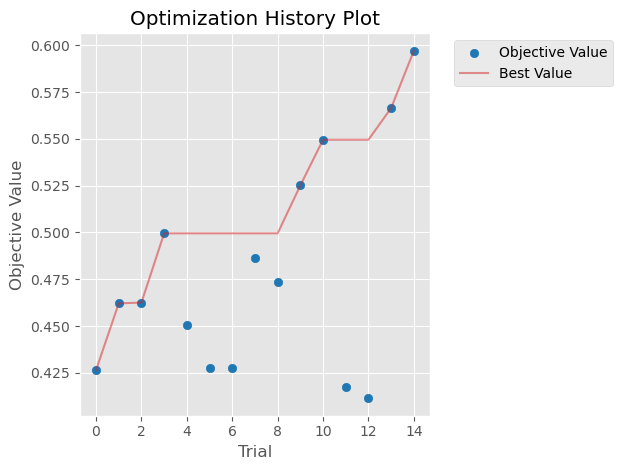

Saved outputs\optuna_ppo_importance.png


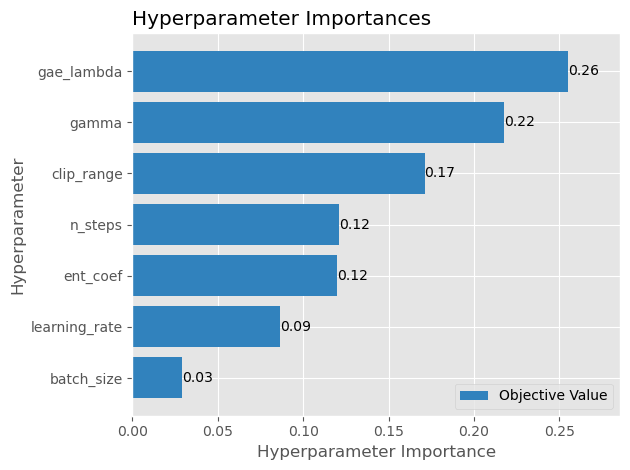

[I 2026-05-31 15:30:28,052] A new study created in memory with name: A2C_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:31:45,090] Trial 0 finished with value: 0.42314999999999997 and parameters: {'learning_rate': 0.006764362607113861, 'n_steps': 8, 'gamma': 0.961033602228737, 'gae_lambda': 0.9213974505900608, 'ent_coef': 0.0012843513791490414}. Best is trial 0 with value: 0.42314999999999997.


[a2c_optuna_t0] All      n=  50  return=0.4231  survival=52.0%
[a2c_optuna_t0] Clean    n=  27  return=0.4866  survival=59.3%
[a2c_optuna_t0] Noisy    n=  12  return=0.4908  survival=58.3%
[a2c_optuna_t0] Missing  n=  11  return=0.3714  survival=45.5%
[a2c_optuna_t0] Acute    n=   5  return=-0.0840  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:33:23,744] Trial 1 finished with value: 0.4175 and parameters: {'learning_rate': 0.00811638915920116, 'n_steps': 5, 'gamma': 0.9963184097860677, 'gae_lambda': 0.9335347367648962, 'ent_coef': 0.001025609275897571}. Best is trial 0 with value: 0.42314999999999997.


...

[a2c_optuna_t12] All      n=  50  return=0.4396  survival=54.0%
[a2c_optuna_t12] Clean    n=  28  return=0.5782  survival=67.9%
[a2c_optuna_t12] Noisy    n=   7  return=0.3050  survival=42.9%
[a2c_optuna_t12] Missing  n=  13  return=0.3619  survival=46.2%
[a2c_optuna_t12] Acute    n=   5  return=-0.0790  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:48:16,758] Trial 13 finished with value: 0.50505 and parameters: {'learning_rate': 0.0006797478232214761, 'n_steps': 8, 'gamma': 0.9895439316041552, 'gae_lambda': 0.9723029669901102, 'ent_coef': 0.008474697384219562}. Best is trial 3 with value: 0.54985.


[a2c_optuna_t13] All      n=  50  return=0.5050  survival=60.0%
[a2c_optuna_t13] Clean    n=  41  return=0.5172  survival=61.0%
[a2c_optuna_t13] Noisy    n=   5  return=0.7335  survival=80.0%
[a2c_optuna_t13] Missing  n=   4  return=0.6837  survival=75.0%
[a2c_optuna_t13] Acute    n=   2  return=-0.1913  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-31 15:49:29,690] Trial 14 finished with value: 0.4203 and parameters: {'learning_rate': 0.0029762037330066196, 'n_steps': 8, 'gamma': 0.9724639689259712, 'gae_lambda': 0.9677254138000144, 'ent_coef': 0.0004607933557383264}. Best is trial 3 with value: 0.54985.


[a2c_optuna_t14] All      n=  50  return=0.4203  survival=54.0%
[a2c_optuna_t14] Clean    n=  33  return=0.5087  survival=63.6%
[a2c_optuna_t14] Noisy    n=   6  return=0.3621  survival=50.0%
[a2c_optuna_t14] Missing  n=  10  return=0.3883  survival=50.0%
[a2c_optuna_t14] Acute    n=   4  return=-0.1375  survival=0.0%

[A2C] Best value: 0.5498
[A2C] Best params: {'learning_rate': 0.0012682675498757593, 'n_steps': 8, 'gamma': 0.9574462374081512, 'gae_lambda': 0.9181433210186519, 'ent_coef': 0.00025562180911352286}
Saved outputs\optuna_a2c_history.png


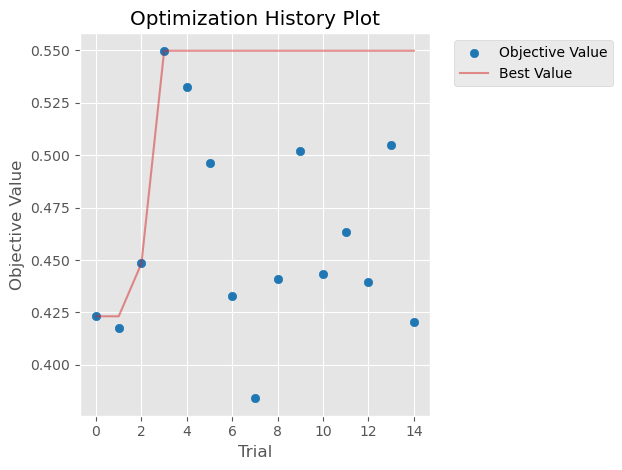

Saved outputs\optuna_a2c_importance.png


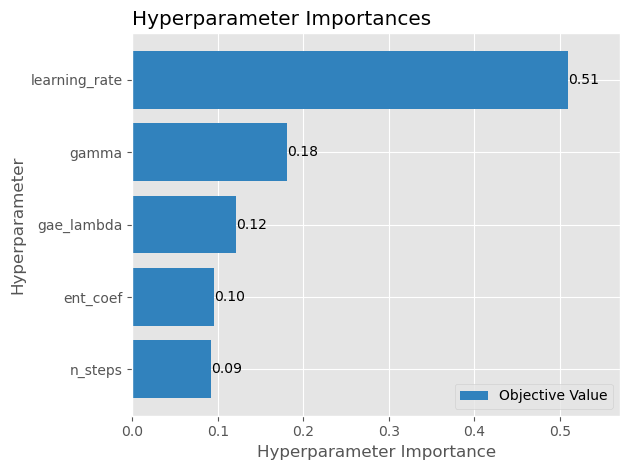

DQN: best return=0.5470  params={'learning_rate': 1.4834994613459502e-05, 'buffer_size': 100000, 'batch_size': 64, 'gamma': 0.9906175826277405, 'train_freq': 4, 'exploration_fraction': 0.3356359763778302, 'target_update_interval': 1000}
PPO: best return=0.5971  params={'n_steps': 256, 'learning_rate': 0.00019816091908275718, 'batch_size': 128, 'gamma': 0.9869978269913328, 'gae_lambda': 0.9581409118906566, 'clip_range': 0.3, 'ent_coef': 0.003350299841011682}
A2C: best return=0.5498  params={'learning_rate': 0.0012682675498757593, 'n_steps': 8, 'gamma': 0.9574462374081512, 'gae_lambda': 0.9181433210186519, 'ent_coef': 0.00025562180911352286}
Best params saved to optuna_best_params.json


In [34]:
studies = {}
for algo in ["DQN", "PPO", "A2C"]:
    studies[algo] = srl.tune(algo, n_trials=15, timesteps=50_000, normalize=True)
    srl.save_optuna_plots(studies[algo], name=algo)

for algo, study in studies.items():
    print(f"{algo}: best return={study.best_value:.4f}  params={study.best_params}")

# Guarda os melhores params em disco (util se fizeres restart ao kernel)
import json as _json
with open("optuna_best_params.json", "w") as f:
    _json.dump({algo: study.best_params for algo, study in studies.items()}, f, indent=2)
print("Best params saved to optuna_best_params.json")

[DQN] melhor trial=14  declive=+0.16079/100k steps
[PPO] melhor trial=5  declive=-0.47750/100k steps
[A2C] melhor trial=3  declive=+0.68353/100k steps
Saved outputs\configB_optuna_best_curves.png


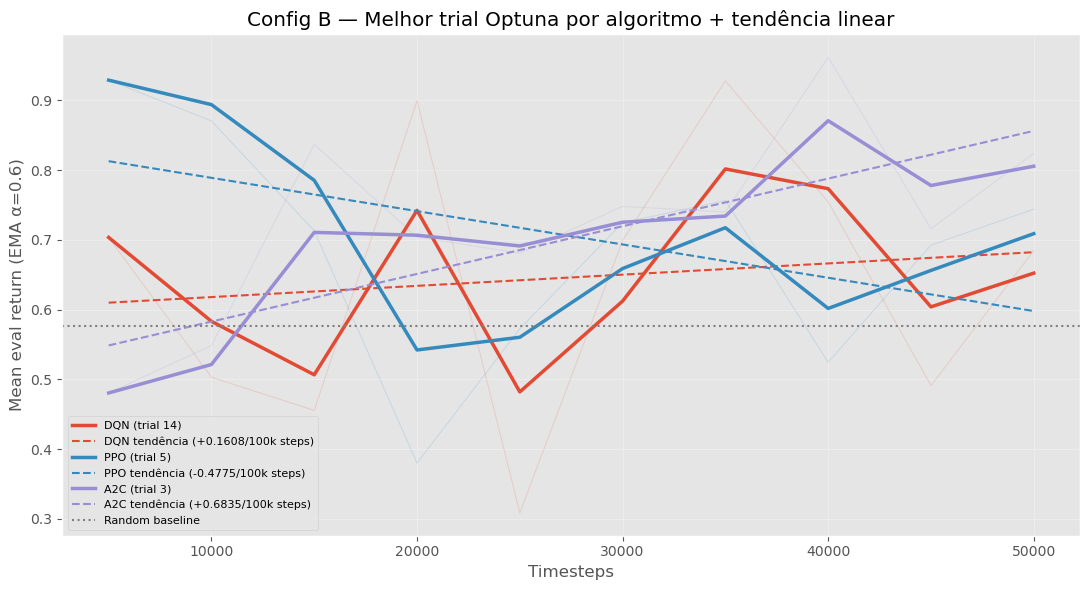

'outputs\\configB_optuna_best_curves.png'

In [35]:
# Não precisas dos studies em memória — lê os logs em disco
srl.plot_best_trial_curves(
    ['DQN', 'PPO', 'A2C'],   # lista de nomes em vez do dict de studies
    baseline=RANDOM_RETURN
)

### (Optional) retrain with the best params found

Plug Optuna's best hyperparameters into a full-budget run.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[dqn_tuned] training complete (1,000,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_tuned] training complete (1,000,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[a2c_tuned] training complete (1,000,000 steps).
Saved outputs\configB_all_tuned_curves.png


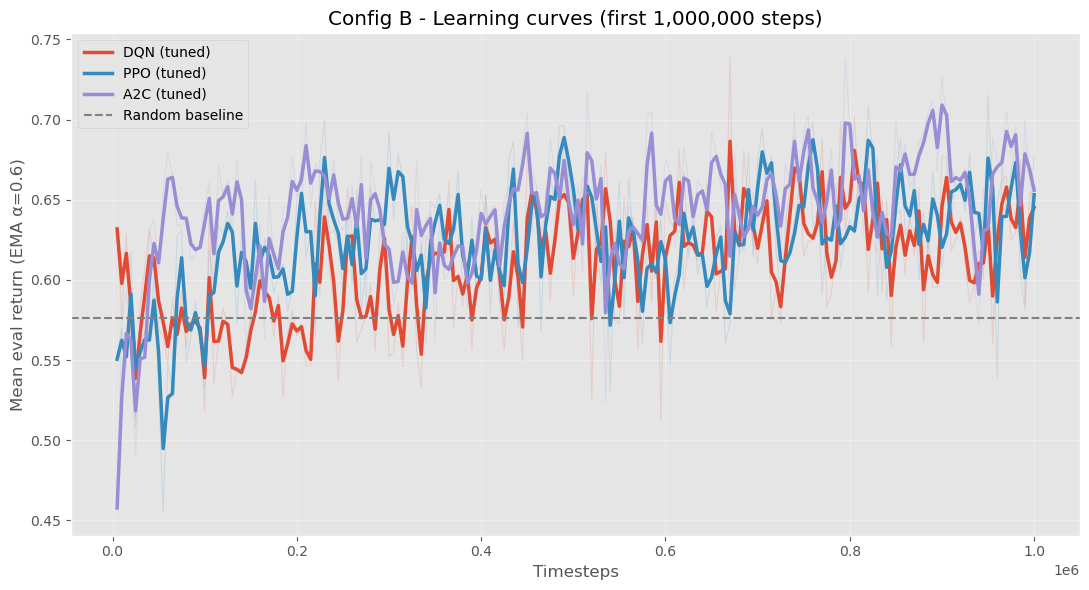

Saved outputs\configB_all_tuned_curves.png


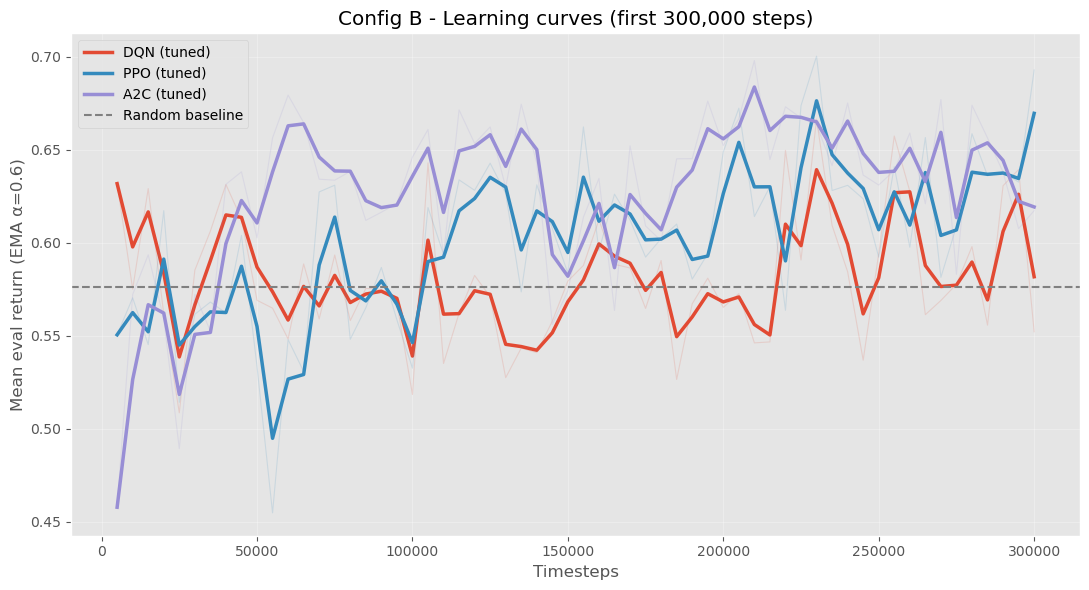

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_tuned] All      n=1000  return=0.6626  survival=70.8%
[dqn_tuned] Clean    n= 659  return=0.7209  survival=76.6%
[dqn_tuned] Noisy    n= 150  return=0.6803  survival=72.7%
[dqn_tuned] Missing  n= 160  return=0.6620  survival=70.6%
[dqn_tuned] Acute    n=  74  return=-0.0449  survival=0.0%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_tuned] All      n=1000  return=0.6360  survival=66.6%
[ppo_tuned] Clean    n= 700  return=0.6786  survival=70.9%
[ppo_tuned] Noisy    n= 148  return=0.6363  survival=66.2%
[ppo_tuned] Missing  n= 132  return=0.6105  survival=64.4%
[ppo_tuned] Acute    n=  62  

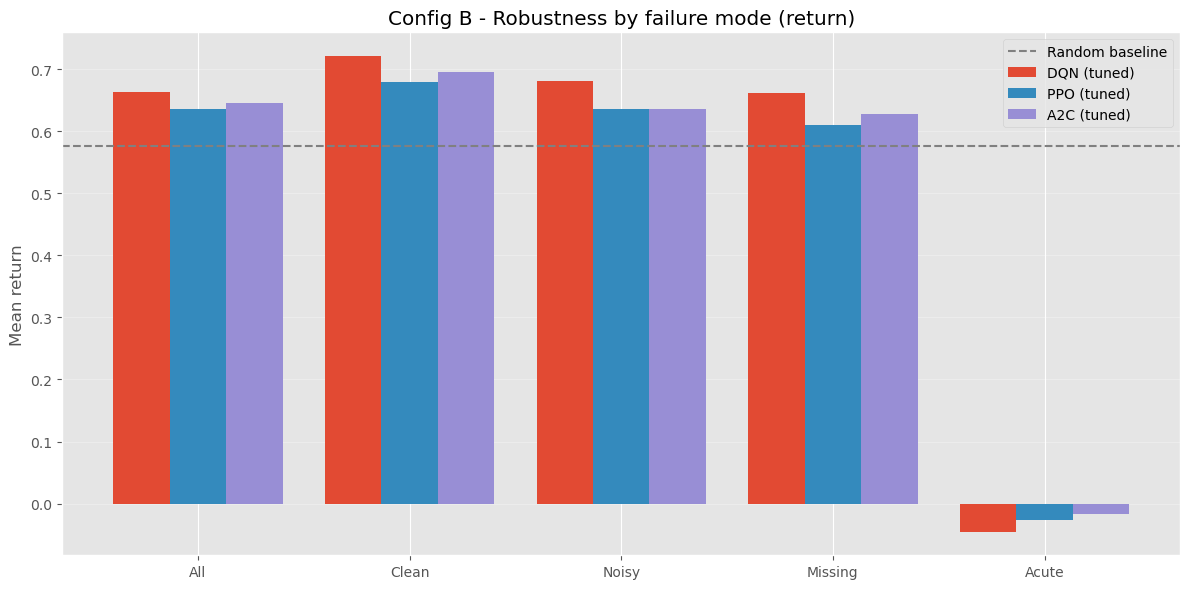

'outputs\\configB_tuned_robustness.png'

In [36]:
TIMESTEPS_TUNED = 1_000_000

tuned_tags = {}
# Só o que faltou
for best_algo in ['DQN', 'PPO', 'A2C']:  # DQN já está feito
    best_hp = dict(studies[best_algo].best_params)
    _, tag = srl.train_agent(
        best_algo, timesteps=1_000_000, normalize=True,
        hyperparams=best_hp, tag=f'{best_algo.lower()}_tuned',
        eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL,
    )
    tuned_tags[best_algo] = tag

# Curva comparativa dos 3 tunados (zoom nos primeiros 300k onde se ve a subida)
srl.plot_learning_curves(
    {tuned_tags["DQN"]: "DQN (tuned)",
     tuned_tags["PPO"]: "PPO (tuned)",
     tuned_tags["A2C"]: "A2C (tuned)"},
    baseline=RANDOM_RETURN,
    zoom_steps=1_000_000,
    filename="configB_all_tuned_curves.png",
)

srl.plot_learning_curves(
    {tuned_tags["DQN"]: "DQN (tuned)",
     tuned_tags["PPO"]: "PPO (tuned)",
     tuned_tags["A2C"]: "A2C (tuned)"},
    baseline=RANDOM_RETURN,
    zoom_steps=300_000,
    filename="configB_all_tuned_curves.png",
)

# Avaliacao de robustez dos tunados
results_tuned = {
    f"{algo} (tuned)": srl.evaluate_conditions(tag, algo, n_episodes=N_EVAL_EPISODES)
    for algo, tag in tuned_tags.items()
}
srl.results_table(results_tuned, random_ret=RANDOM_RETURN)
srl.plot_robustness(results_tuned, metric="return", baseline=RANDOM_RETURN,
                    filename="configB_tuned_robustness.png")

  [DQN (tuned)] declive = +0.00688 por 100k passos (a subir)
Saved outputs\configB_dqn_tuned_trend.png


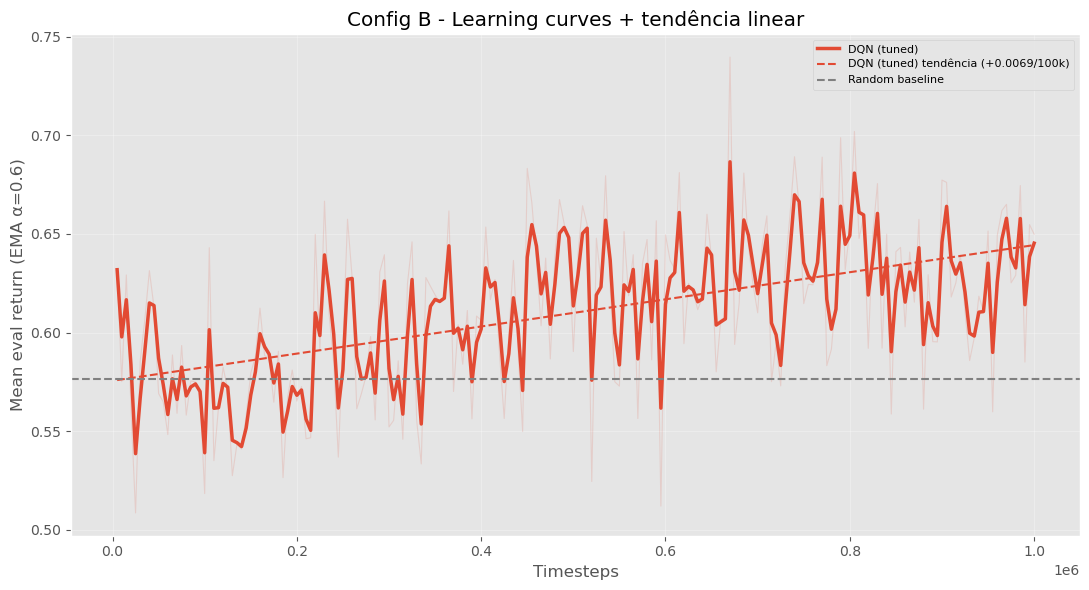

  [PPO (tuned)] declive = +0.00575 por 100k passos (a subir)
Saved outputs\configB_ppo_tuned_trend.png


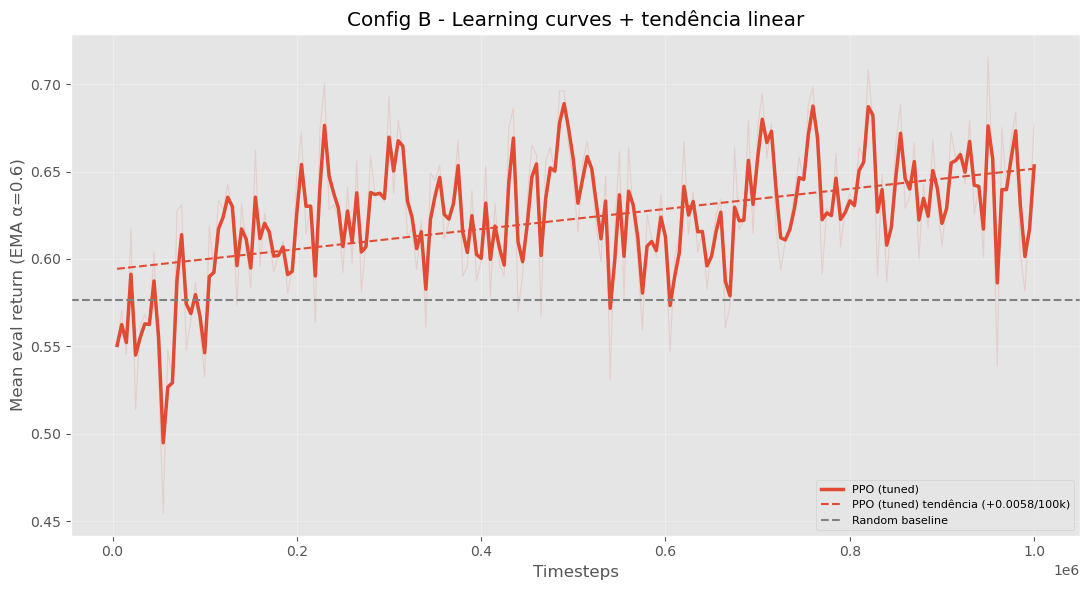

  [A2C (tuned)] declive = +0.00598 por 100k passos (a subir)
Saved outputs\configB_a2c_tuned_trend.png


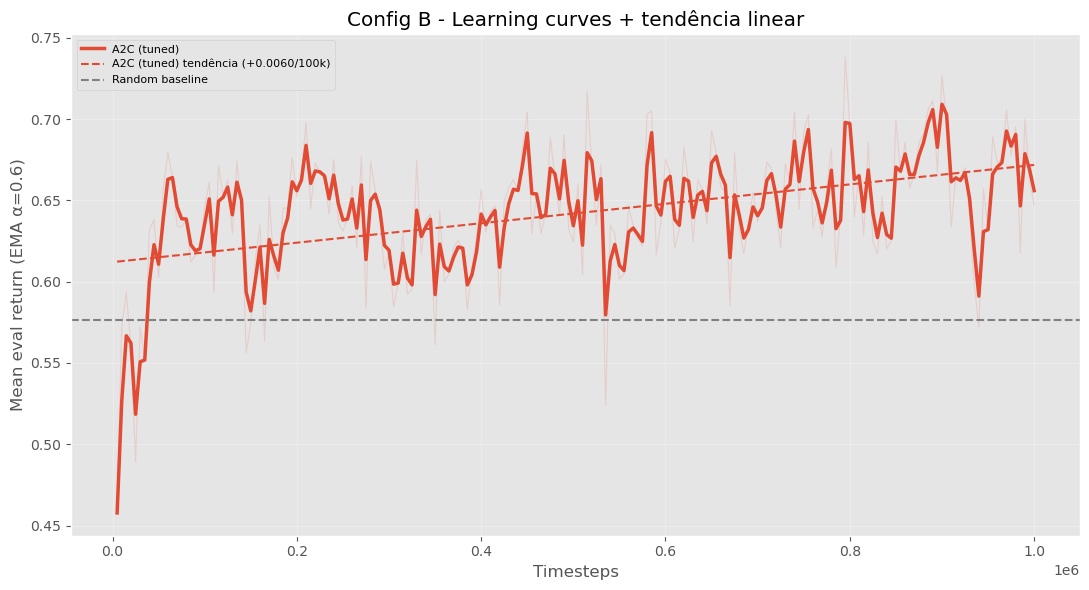

In [37]:
# Um plot separado por algoritmo — curva completa + reta de tendência
for algo, tag in tuned_tags.items():
    srl.plot_learning_curves(
        {tag: f"{algo} (tuned)"},
        baseline=RANDOM_RETURN,
        show_trend=True,
        filename=f"configB_{algo.lower()}_tuned_trend.png",
    )

  [DQN (tuned)] declive = +0.00688/100k passos  a subir ↑
  [PPO (tuned)] declive = +0.00575/100k passos  a subir ↑
  [A2C (tuned)] declive = +0.00598/100k passos  a subir ↑
Saved outputs\configB_tuned_grid.png


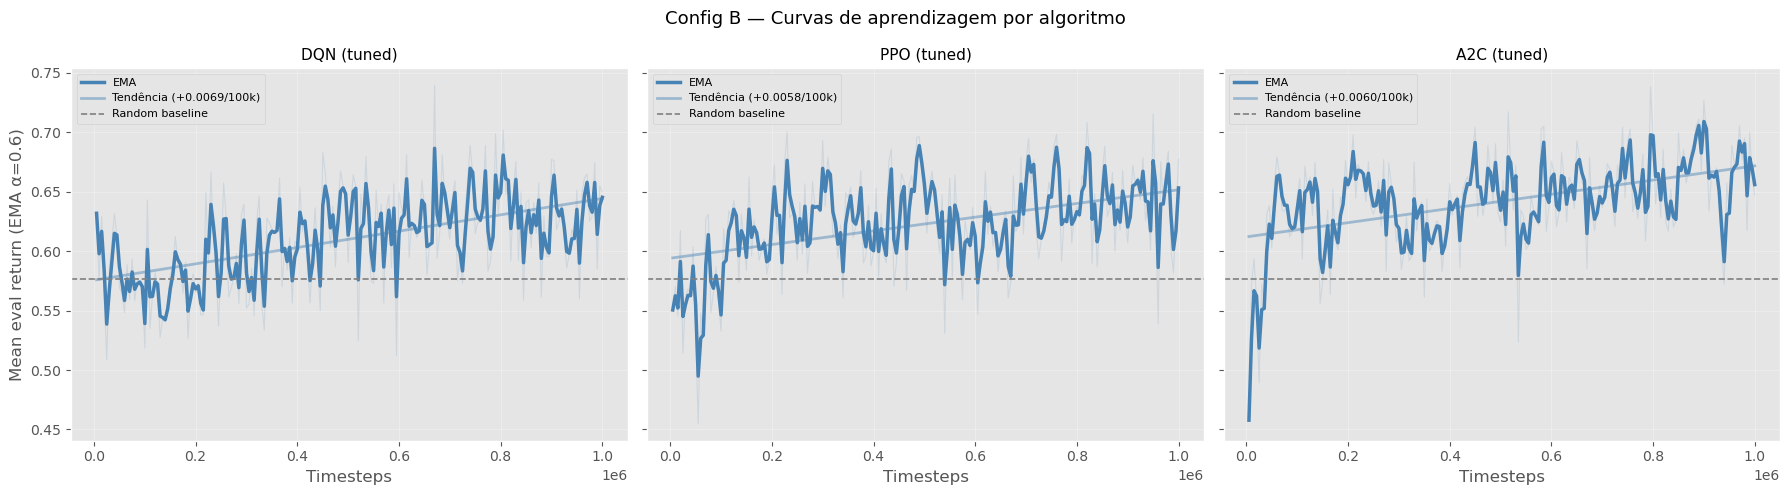

'outputs\\configB_tuned_grid.png'

In [39]:
srl.plot_curves_grid(
    {'dqn_tuned': 'DQN (tuned)',
     'ppo_tuned': 'PPO (tuned)',
     'a2c_tuned': 'A2C (tuned)'},
    baseline=RANDOM_RETURN,
    filename='configB_tuned_grid.png',
)